<a href="https://colab.research.google.com/github/Sherlysukmadira/SpeechProcessing-Sherly-Sukmadira-Putri/blob/main/2311532015_Sherly_Sukmadira_Putri_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install librosa matplotlib numpy scipy soundfile

Import library librosa di mana librosa ialah library python yang khusus untuk audio analysis dan speech processing.   Library ini digunakan untuk :
1.   Membaca file audio
2.   Membuat spectogram
3. Preprocessing audio
4. Feature extraction



In [5]:
import librosa
import librosa.display  #untuk menampilkan grafik audio
import matplotlib.pyplot as plt  #Library untuk membuat grafik atau visualisasi di Python.
import numpy as np #Library untuk operasi matematika dan array.

In [11]:
audio_path = "2311532015-Sherly Sukmadira Putri-audio.wav"
signal, sr = librosa.load(audio_path, sr=None) #membaca file audio
#signal berisi data sinyal audio dalam bentuk array angka
#sr = jumlah sampel suara perdetik, jika sr =16000 berarti dalam 1 detik ada 16000 sampel suara
total_samples = len(signal)
print("Jumlah sampel audio keseluruhan:", total_samples)

print("Sampling rate:", sr)
print("Durasi:", len(signal)/sr, "detik")

Jumlah sampel audio keseluruhan: 3340288
Sampling rate: 48000
Durasi: 69.58933333333333 detik


Dari hasil di atas artiya audio memiliki 48000 sampel per detik dengan durasi 69,589 detik

di mana rumus durasi = jumlah sampel/sampling rate

MEMVISUALISASIKAN WAVEFORM

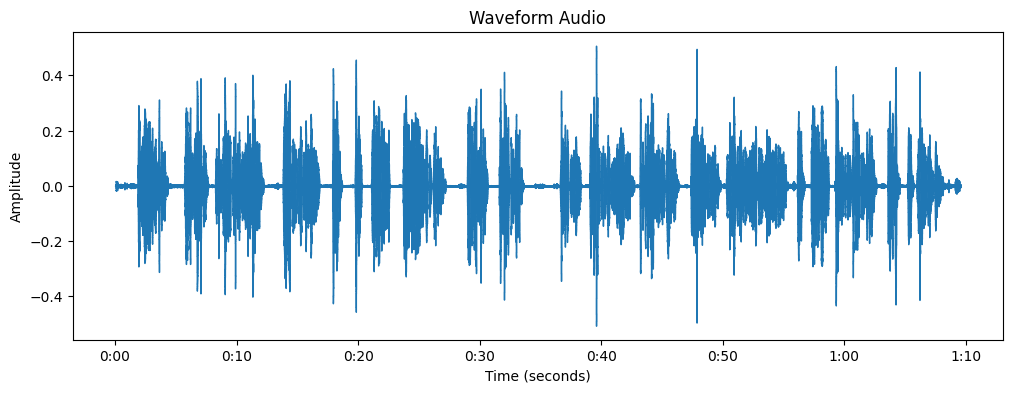

In [12]:
plt.figure(figsize=(12,4)) #membuat kanvas grafik

librosa.display.waveshow(signal, sr=sr) #menampilkan grafik sinyal audio terhadap waktu
#signal = data amplitudo audio yang dibaca dari file
#sr = sampling rate audio

plt.title("Waveform Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

X = waktu
Y = amplitudo

waktu (t) = n (index sampel)/(sampling rate)sr



**Interpretasi grafik **

pada bagian suara yang keras gelombangnya tinggi dan amplitudonya besar sementara pada bagian suara yang kecil gelombang atau amplitudonya kecil.

Grafik di atas sangat khas untuk suara manusia di mana terdapat gumpalan-gumpalan bitu yang terpisah oleh garis datar tipis biasanya garis ini merupakan jeda antar kalimat atau saat pembicara mengambil napas.

Dinamika suara cukup konsisten, namun ada beberapa lonjakan tajam seperti pada detik ke 40, dimana pada detik ke 40 ini merupakan suara penekanan dari pembicara

pada bagian awal di detik ke 0:00 terlihat tenang dan jeda, kemungkinan adalah background nise sebelum mulai berbicara

MEMBUAT SPECTOGRAM

Pada bagian ini kita akan melihat suara dalam domain frekuensi terhadap waktu bukan hanya amplitudo seperti wavefromm

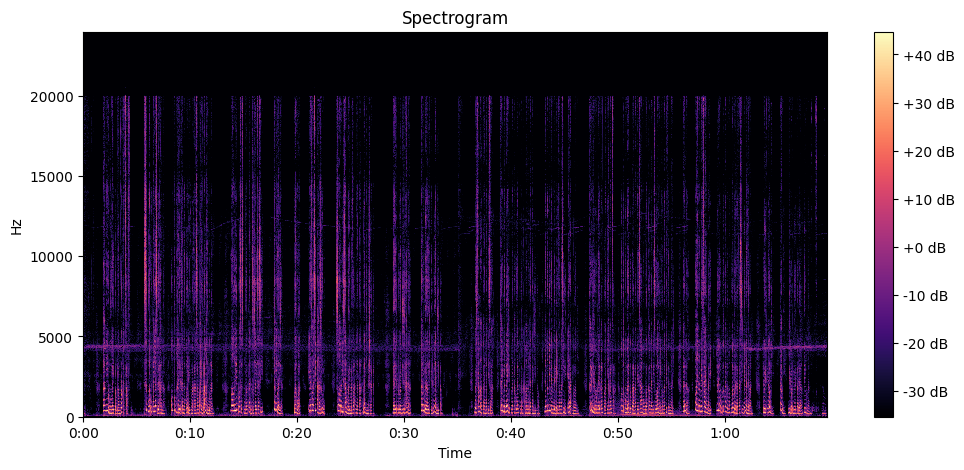

In [14]:
spectrogram = librosa.stft(signal)

spectrogram_db = librosa.amplitude_to_db(abs(spectrogram)) #Menghitung STFT
#STFT = Short-Time Fourier Transform
# STFT bertujuan utnuk mengubah sinyal domain waktu menjadi frekuensi
#abs(spectrogram) bertujuan untuk mengambil magnitude
#kita juga mengubah ke decibel (dB) Karena amplitudo frekuensi bisa sangat besar variasinya. Skala decibel membuat visualisasi lebih mudah dilihat.

plt.figure(figsize=(12,5))


#Menampilkan spectogram
librosa.display.specshow(
    spectrogram_db, #data frekuensi yang sudah dihitung
    sr=sr,  #sampling rate untuk menentukan skala frekuensi
    x_axis='time', #sumbu X menjadi waktu
    y_axis='hz' #sumbu Y menjadi frekuensi dalam Hertz
    )

plt.colorbar(format='%+2.0f dB') #Colorbar menunjukkan intensitas energi frekuensi. Dimana warna terang berarti energi kuat dan gelap berarti energi lemah

plt.title("Spectrogram")

plt.show()

Grafik Spectrogram di atas enunjukkan distribusi frekuensi suara dari waktu ke waktu. Jika waveform sebelumnya hanya menunjukkan volume, spectrogram ini menunjukkan "warna" atau karakter suaranya.

**Frekuensi dominan**
pada grafik di atas energi utama berada pada rentang 0-2000 Hz. Kita dapat lihat garis-garis horizontal yang sangat terang pada bagian bawah dan ini adalah frekwensi daasar suara manusia.

Frekuensi menengah berada pada 2000-5000 Hz di mana masi terdapat banyak aktivitas energi. ini biasanya berisi artikulasi yang memberikan kejelasan pada ucapan (clarity)

di atas 5000Hz energi mulai melemah (warna ungu gelap/hitam)

**Pola Harmonik**
Terdapat pola harmonik yang sangat jelas. Pada area bawah (0-4000hz) terdapat garis-garis horizontal yang bertumpuk sejajar. Garis-garis terbut ialah harmonics. Dalam suara manusia. pita suara menghasilkan suatu nada dasar dan resonansi mulut/tenggorokan yang menciptakan kelipatan dari nada tersebut. danya garis-garis horizontal yang teratur ini memastikan bahwa audio ini adalah suara bernada (voiced sound) seperti vokal (a, i, u, e, o), bukan sekadar desisan atau noise.

**Distribusi Energi Frekuensi**
1. Konsentrasi energi rendah : Sebagian besar data (dB)terkumpul di bawah 5000Hz. Ini merupakan khas rekaman suara manusia
2. Pola vertikal : Garis-garis vertikal tipis yang muncul tiba-tiba menunjukkan adanya suara letupan atau awal dari sebuah kata (misalnya huruf 'P', 'T', atau 'K').
3. Celah hitam : Area hitam di bagian atas (di atas 20.000 Hz) menunjukkan bahwa tidak ada sinyal sama sekali di sana. I
4. Garis Horizontal Konsisten di ~4.500 Hz: Terlihat ada garis tipis yang terus memanjang secara horizontal. Ini bisa jadi adalah background noise yang konstan, seperti suara kipas angin atau dengung alat elektronik (electronic hum).

PREPROCESSING

1. Normalization


Normalization digunakan untuk menyesuaikan amplitudo sinyal agar berada dalam rentang tertentu (biasanya -1 sampai 1). Ini membuat volume audio lebih stabil dan memudahkan proses analisis selanjutnya.

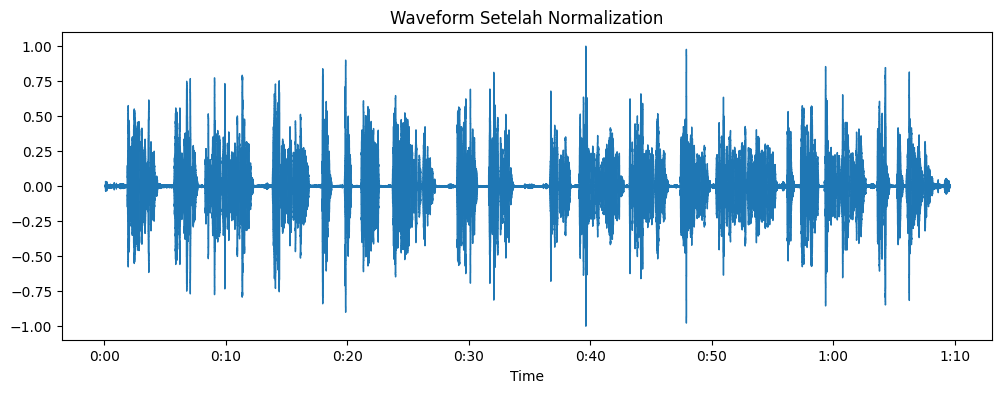

In [16]:
normalized_signal = signal / np.max(np.abs(signal))

#np.abs(signal) Mengambil nilai absolut amplitudo.
#np.max() Mencari amplitudo terbesar dalam sinyal.
#Pembagian signal / max tujuannya agar amplitudo maksimum menjadi 1

#Visualisasi sesudah Normalisasi
plt.figure(figsize=(12,4))
librosa.display.waveshow(normalized_signal, sr=sr)
plt.title("Waveform Setelah Normalization")
plt.show()

Pada grafik awal, amplitudo tertingginya hanya mencapai sekitar 0.5. Setelah dinormalisasi,  puncak tertingginya sekarang menyentuh angka 1.0 (atau -1.0)

2. Silence Removal
bertujuan untuk menghapus bagian audio yang tidak memiliki suara

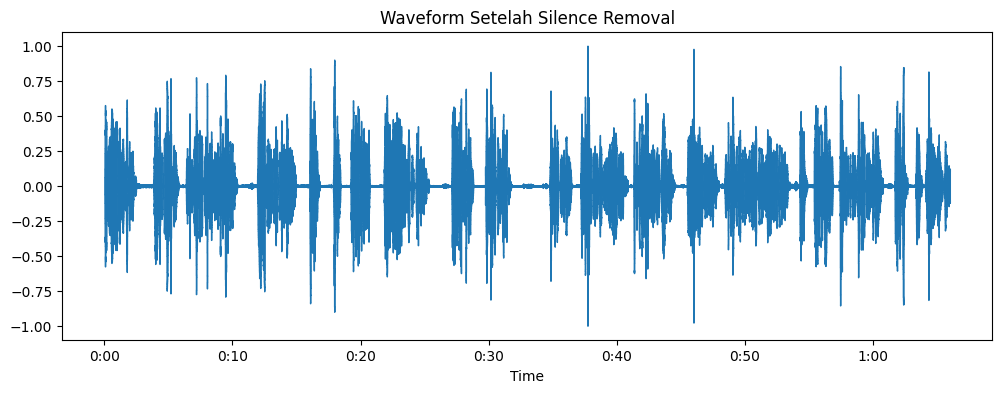

In [19]:
trimmed_signal, index = librosa.effects.trim(normalized_signal, top_db=20)
#top_db=20 Parameter ini menentukan batas energi suara. Jika energi lebih rendah dari batas tersebut maka dianggap silence.

#Visualisasikan hasil
plt.figure(figsize=(12,4))
librosa.display.waveshow(trimmed_signal, sr=sr)
plt.title("Waveform Setelah Silence Removal")
plt.show()

Dapat dilihat bagian pada awal dan akhir telah dihilangkan

3. Noise Reduction
Noise reduction dilakukan untuk mengurangi gangguan suara latar belakang pada rekaman. Metode yang digunakan adalah filtering menggunakan Butterworth filter sehingga sinyal yang dihasilkan menjadi lebih bersih.

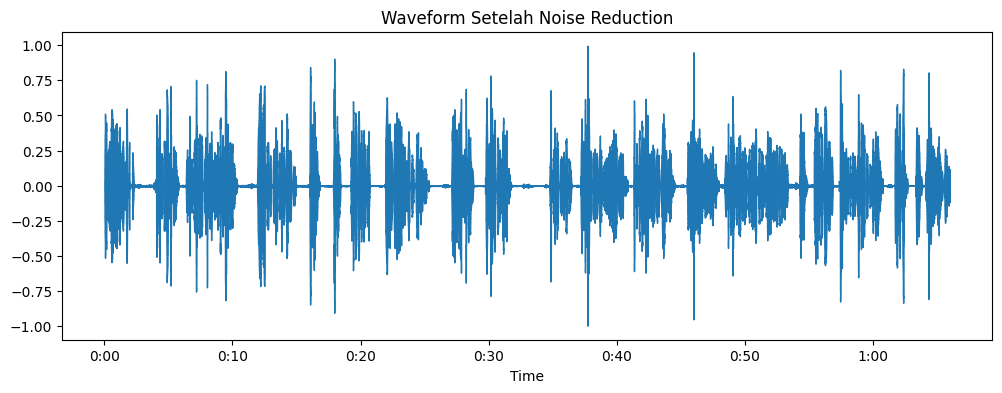

In [21]:
import scipy.signal as sps

b, a = sps.butter(6, 0.1)
#butter() membuat Butterworth filter dengan parameter 6 = orde filter dan 0,1 - cutoff frequency
#angka 6 menunjukan tingkat ketajaman filter di mana filter semakin tajam memisahkan frrekuensi dan noise lebih banyak dipotong
#angka 0.1 adalah frkwensi batas filter
filtered_signal = sps.filtfilt(b, a, trimmed_signal)
#filtfilt() Menerapkan filter pada sinyal tanpa menggeser fase sinyal

#Visualisasi
plt.figure(figsize=(12,4))
librosa.display.waveshow(filtered_signal, sr=sr)
plt.title("Waveform Setelah Noise Reduction")
plt.show()

Perbedaan grafik setelah dilakukan noise reduction sangat tipis dari sebelumnya. Namun jika diperhatikan lebih teliti kita akan melihat garis gumpalan-gumpalan biru yang sebelumnya cukup tebal sekarang menjadi tipis dan hampir lurus sempurna diangka 0

4. Framing
Bertujuan untuk Membagi sinyal audio menjadi potongan kecil (frame).

In [22]:
frame_length = 2048 #jumlah sampel tiap frame
hop_length = 512 #Jarak antar frame

frames = librosa.util.frame(
    filtered_signal,
    frame_length=frame_length,
    hop_length=hop_length
)

Framing dilakukan untuk membagi sinyal audio menjadi potongan kecil sehingga analisis dapat dilakukan pada interval waktu yang lebih pendek. Setelah framing, diterapkan windowing menggunakan Hamming window untuk mengurangi efek diskontinuitas pada tepi frame dan meminimalkan spectral leakage.

5. Windowing
Bertujuan untuk mengurangi diskontinuitas di tepi frame.

In [26]:
window = np.hamming(frame_length)
#np.hamming() untuk Membuat Hamming window.

windowed_frames = frames * window[:, None] #setiap frame dikalikan dengan window.




In [29]:
#Menyimpan audio hasil processing
import soundfile as sf

sf.write("2311532015-Sherly Sukmadira Putri-preprocessing.wav", filtered_signal, sr)

In [30]:
#Menyimpan frame Windowing
for i in range(5): #kita menyimpam 5 windowing
    sf.write(f"2311532015-Sherly Sukmadira Putri-windowing-{i}.wav", windowed_frames[:,i], sr)

Windowing dilakukan setelah proses framing dengan menggunakan Hamming window. Proses ini bertujuan untuk mengurangi diskontinuitas pada tepi frame sehingga dapat meminimalkan spectral leakage saat analisis frekuensi dilakukan. Setiap frame memiliki durasi yang sangat pendek sehingga file hasil windowing terdengar seperti potongan kecil dari sinyal audio asli